## General Setup

In [1]:
import sys
from pathlib import Path

# notebooks/ -> repo root
REPO_ROOT = Path.cwd().resolve()
print(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
sys.path.append("..")

/Users/tzhang04/Desktop/active-passive-alternations/notebooks


In [30]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import normaltest, ttest_rel, wilcoxon
from sklearn.preprocessing import StandardScaler
from IPython.display import Markdown, display
from src.uid import *

In [3]:
import conllu
from conllu import Token, parse, parse_tree
from pyinflect import getAllInflections, getInflection
from src.utils import *
from src.units.word import *
from src.units.sentence import *

## Test Feature Extraction

### Load documents

In [17]:
ud_path = "../data/en_gum-ud-dev.conllu"
docs = iter_counterfactual_docs(ud_path)

In [18]:
# look for sentences with key
doc = [doc for doc in docs if doc[0] == 'cf::GUM_conversation_grounded::22::a>p'][0]
key_sents = []
for doc in docs:
    for sent in doc[2]:
        if " her " in sent.text:
            # print("Found it")
            key_sents.append(sent)

In [19]:
# [sent.text for sent in key_sents]

In [20]:
# key_sents[0]

In [21]:
nlp = stanza.MultilingualPipeline()

2026-04-05 14:40:38 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-04-05 14:40:39 INFO: Downloaded file to /Users/tzhang04/stanza_resources/resources.json
2026-04-05 14:40:39 INFO: Loading these models for language: multilingual ():
| Processor | Package |
-----------------------
| langid    | ud      |

2026-04-05 14:40:39 INFO: Using device: cpu
2026-04-05 14:40:39 INFO: Loading: langid
2026-04-05 14:40:39 INFO: Done loading processors!


In [23]:
# nlp("My mom picked up a dog in the park.")

In [6]:
doc_id, sents, doc = docs[0]

In [7]:
for doc_id, sents, doc in docs:
    for sent in doc:
        try:
            active_sent = ActiveSentence(sent)
        except:
            continue

In [8]:
active_sent.text

'If you wash your overalls alone or in a light load, use about half the detergent called for and less water.'

In [9]:
active_sent.active_subject_word

{'id': 2,
 'form': 'you',
 'lemma': 'you',
 'upos': 'PRON',
 'xpos': 'PRP',
 'feats': {'Case': 'Nom', 'Number': 'Sing', 'Person': '2', 'PronType': 'Prs'},
 'head': 3,
 'deprel': 'nsubj',
 'deps': [('nsubj', 3)],
 'misc': {'Entity': '(3-person-giv:inact-nnsnn-cf1-1-ana)'},
 'inflection': 'PRP',
 'children': []}

In [10]:
tok, model, device = load_lm('distilgpt2', device='mps')
unigram = UnigramLM(tok)
unigram.fit("\n".join(["\n".join(doc[1]) for doc in docs]), uid_unit='word')

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 2572.36it/s, Materializing param=transformer.wte.weight]            
GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (487324 > 1024). Running this sequence through the model will result in indexing errors


In [11]:
result = ling_features(active_sent, tok, unigram, uid_unit='word')

In [12]:
unigram.model.get('you', 0)

0.01065558639014376

In [13]:
unigram('you')

(array([0.01065559]), np.float64(0.01065558639014376))

In [15]:
result

{'agent': [{'id': 2,
   'form': 'you',
   'lemma': 'you',
   'upos': 'PRON',
   'xpos': 'PRP',
   'feats': {'Case': 'Nom',
    'Number': 'Sing',
    'Person': '2',
    'PronType': 'Prs'},
   'head': 3,
   'deprel': 'nsubj',
   'deps': [('nsubj', 3)],
   'misc': {'Entity': '(3-person-giv:inact-nnsnn-cf1-1-ana)'},
   'inflection': 'PRP',
   'children': []}],
 'agent_len': 1,
 'agent_unigram_prob': np.float64(0.01065558639014376),
 'agent_is_pronoun': True,
 'agent_is_plural': False,
 'patient': [{'id': 4,
   'form': 'your',
   'lemma': 'your',
   'upos': 'PRON',
   'xpos': 'PRP$',
   'feats': {'Case': 'Gen',
    'Number': 'Sing',
    'Person': '2',
    'Poss': 'Yes',
    'PronType': 'Prs'},
   'head': 5,
   'deprel': 'nmod:poss',
   'deps': [('nmod:poss', 5)],
   'misc': {'Entity': '(1-object-giv:inact-sssss-cf2-2-coref(3-person-giv:act-nnsnn-cf1-1-ana)'},
   'inflection': 'PRP$',
   'children': []},
  {'id': 5,
   'form': 'overalls',
   'lemma': 'overall',
   'upos': 'NOUN',
   'xpos': 

In [13]:
# Animacy from WordNet
import nltk
nltk.download("wordnet")
from nltk.corpus import wordnet as wn

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tzhang04/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [14]:
syn = wn.synsets("we", pos=wn.NOUN)
i = 0
syn[i], syn[i].lexname(), syn[i].definition()

IndexError: list index out of range

In [16]:
# Get synsets for the verb 'run'
for synset in wn.synsets('run', pos=wn.VERB):
    print(synset.name(), ":", synset.definition())

run.v.01 : move fast by using one's feet, with one foot off the ground at any given time
scat.v.01 : flee; take to one's heels; cut and run
run.v.03 : stretch out over a distance, space, time, or scope; run or extend between two points or beyond a certain point
operate.v.01 : direct or control; projects, businesses, etc.
run.v.05 : have a particular form
run.v.06 : move along, of liquids
function.v.01 : perform as expected when applied
range.v.01 : change or be different within limits
campaign.v.01 : run, stand, or compete for an office or a position
play.v.18 : cause to emit recorded audio or video
run.v.11 : move about freely and without restraint, or act as if running around in an uncontrolled way
tend.v.01 : have a tendency or disposition to do or be something; be inclined
run.v.13 : be operating, running or functioning
run.v.14 : change from one state to another
run.v.15 : cause to perform
run.v.16 : be affected by; be subjected to
prevail.v.03 : continue to exist
run.v.18 : occur

In [90]:
is_animate("we")

False

### Check feature extraction outputs

In [24]:
out = pd.read_csv("../temp/cf_word_sentence_uid_chkpt.csv")

In [25]:
ling_features = ["doc_id", "sent_idx"]
for name in ['agent', 'patient']:
    ling_features.extend([
        f"{name}",
        f"{name}_len", 
        f"{name}_unigram_logprob",
        f"{name}_is_pronoun",
        f"{name}_is_plural",
        f"{name}_is_animate",
        f"{name}_is_definite",])

In [26]:
ling_feat_out = out[['sentence'] + ling_features]

In [27]:
ling_feat_out[ling_feat_out['agent_is_definite']].head()

,sentence,doc_id,sent_idx,agent,agent_len,agent_unigram_logprob,agent_is_pronoun,agent_is_plural,agent_is_animate,agent_is_definite,patient,patient_len,patient_unigram_logprob,patient_is_pronoun,patient_is_plural,patient_is_animate,patient_is_definite
8,Such a scenario may be found in different situ...,f::GUM_academic_exposure::-1::og,6,one,1,-6.257701,True,False,True,True,a language,2,-12.056551,False,False,False,False
9,Such a scenario may be found in different situ...,f::GUM_academic_exposure::-1::og,6,one,1,-6.257701,True,False,True,True,a language,2,-12.056551,False,False,False,False
10,Such a scenario may be found in different situ...,f::GUM_academic_exposure::-1::og,6,one,1,-6.257701,True,False,True,True,a language,2,-12.056551,False,False,False,False
11,Such a scenario may be found in different situ...,f::GUM_academic_exposure::-1::og,6,one,1,-6.257701,True,False,True,True,a language,2,-12.056551,False,False,False,False
12,Such a scenario may be found in different situ...,f::GUM_academic_exposure::-1::og,6,one,1,-6.257701,True,False,True,True,a language,2,-12.056551,False,False,False,False


In [28]:
doc = [doc for doc in docs if doc[0] == 'f::GUM_academic_exposure::-1::og'][0]
is_definite(doc[2][13][18])

False

In [29]:
is_definite(doc[2][13].active_subject_word)

False

## Logistic Regression Model Experiments

### Setup

#### Imports

In [280]:
# Import
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score
import statsmodels.api as sm
SEED = 169
BOOTSTRAP = False
RESAMPLE = True

#### Utils

In [260]:
# Utils
def extract_sents_of_interest(doc_sents: pd.DataFrame):
    converted_indices = doc_sents['conv_idx'].unique()
    sents_of_interest = []
    for i, sent in doc_sents.iterrows():
        if ((sent['sent_idx'] in converted_indices)
            and 
            (sent['conv_idx'] in [sent['sent_idx'], -1])):
            sents_of_interest.append(sent)
    return pd.DataFrame(sents_of_interest)

def check_passive(f_cf_pair: pd.DataFrame):
    conversion = f_cf_pair['conversion'].unique()
    if 'a>p' in conversion:
        return f_cf_pair.assign(passive=[False if fact else True for fact in f_cf_pair['factual']])
    elif 'p>a' in conversion:
        return f_cf_pair.assign(passive=[True if fact else False for fact in f_cf_pair['factual']])
    
def check_conversion(row):
    mapping = {
        "p>a": "P to A",
        "a>p": "A to P"
    }
    if row['conversion'] != 'og':
        return mapping[row['conversion']]
    if row['passive']:
        return 'P to A'
    return 'A to P'

def perm_test(data, 
              label_column, 
              value_column, 
              n_permutations, 
              agg_fn=np.mean, 
              test_stat=lambda a, b: np.abs(a - b),
              compare_fn=lambda sim, obs: sim >= obs,
              ):
    value_a, value_b = data[label_column].unique()
    print("Labels in order: ", value_a, value_b)
    obs_a = agg_fn(data.loc[data[label_column] == value_a, value_column])
    obs_b = agg_fn(data.loc[data[label_column] == value_b, value_column])
    obs_stat = test_stat(obs_a, obs_b)
    
    sim_stats = []
    for _ in range(n_permutations):
        sim_labels = np.random.permutation(data[label_column])
        sim_a = agg_fn(data.loc[sim_labels == value_a, value_column])
        sim_b = agg_fn(data.loc[sim_labels == value_b, value_column])
        sim_stat = test_stat(sim_a, sim_b)
        sim_stats.append(sim_stat)
    sim_stats = np.array(sim_stats)
    return obs_stat, sim_stats, (compare_fn(sim_stats, obs_stat)).mean()

def evaluate_model(model, X, y, plot=True):
    y_score = model.predict(X)
    y_pred = y_score > 0.5
    cm = confusion_matrix(y, y_pred)
    # fpr, tpr, thresh = roc_curve(y, y_score)
    roc_auc = roc_auc_score(y, y_score)
    acc = accuracy_score(y, y_pred)

    print("Accuracy: %.2f" % acc)
    print("ROC-AUC: %.2f" % roc_auc)
    if plot:
        sns.heatmap(cm, annot=True)
        plt.ylabel("Predicted")
        plt.xlabel("Actual")
        plt.title("Confusion Matrix")
    
    return cm, roc_auc, acc

#### Data setup

In [376]:
data_path = "../temp/cf_word_sentence_uid.csv"
data_path = Path(data_path)
uid_df = pd.read_csv(data_path)
uid_df.shape

(6480, 32)

In [377]:
_, uid_unit, uid_level, _ = data_path.stem.split("_")[:4]
context_lvls = ['document']
plot_suffix = f"_{uid_unit}_{uid_level}"

In [378]:
uid_df[['factual', 'doc_name', 'conv_idx', 'conversion']] = uid_df['doc_id'].str.split("::", expand=True)
uid_df['conv_idx'] = uid_df['conv_idx'].astype(int)
uid_df['surp_slor'] *= -1

In [379]:
uid_df.columns

Index(['Unnamed: 0', 'doc_id', 'sent_idx', 'context', 'sentence', 'tokens',
       'units', 'raw_surps', 'raw_uni_surps', 'surp_mean', 'surp_slor',
       'uid_std', 'uid_mad', 'uid_pwd', 'uid_range', 'uid_cv', 'uid_slope',
       'uid_len', 'agent', 'agent_len', 'agent_unigram_logprob',
       'agent_is_pronoun', 'agent_is_plural', 'agent_is_animate',
       'agent_is_definite', 'patient', 'patient_len',
       'patient_unigram_logprob', 'patient_is_pronoun', 'patient_is_plural',
       'patient_is_animate', 'patient_is_definite', 'factual', 'doc_name',
       'conv_idx', 'conversion'],
      dtype='str')

In [380]:
sents_of_interest = uid_df.groupby("doc_name").apply(extract_sents_of_interest).reset_index().drop(columns="level_1")
sents_of_interest.shape

(6480, 36)

In [381]:
cf_comparison = sents_of_interest[sents_of_interest['context'].isin(context_lvls)].drop(columns=['raw_surps', 'raw_uni_surps'])
cf_comparison['factual'] = cf_comparison['factual'] == 'f'
cf_comparison = cf_comparison.groupby(['doc_id', 'sent_idx', 'context']).first().sort_values(by=['doc_name', 'sent_idx']).reset_index()
cf_comparison = cf_comparison.groupby(['doc_name', 'sent_idx']).filter(lambda g: g.shape[0] >= len(context_lvls) * 2)
cf_comparison = cf_comparison.groupby(['doc_name', 'sent_idx']).apply(check_passive).reset_index()
cf_comparison['conversion'] = cf_comparison.apply(check_conversion, axis=1)
cf_comparison = cf_comparison[((cf_comparison['patient_unigram_logprob'] != -np.inf) & (cf_comparison['agent_unigram_logprob'] != -np.inf))]
print(cf_comparison.shape)
cf_comparison.head()

(602, 36)


,doc_name,sent_idx,level_2,doc_id,context,Unnamed: 0,sentence,tokens,units,surp_mean,...,patient_len,patient_unigram_logprob,patient_is_pronoun,patient_is_plural,patient_is_animate,patient_is_definite,factual,conv_idx,conversion,passive
2,GUM_academic_exposure,6,2,cf::GUM_academic_exposure::6::a>p,document,83,Such a scenario may be found in different situ...,"['Such', 'Ġa', 'Ġscenario', 'Ġmay', 'Ġbe', 'Ġf...","['Such', 'Ġa', 'Ġscenario', 'Ġmay', 'Ġbe', 'Ġf...",5.794359,...,2,-12.056551,False,False,False,False,False,6,A to P,True
3,GUM_academic_exposure,6,3,f::GUM_academic_exposure::-1::og,document,11,Such a scenario may be found in different situ...,"['Such', 'Ġa', 'Ġscenario', 'Ġmay', 'Ġbe', 'Ġf...","['Such', 'Ġa', 'Ġscenario', 'Ġmay', 'Ġbe', 'Ġf...",5.794359,...,2,-12.056551,False,False,False,False,True,-1,A to P,False
4,GUM_academic_exposure,7,4,cf::GUM_academic_exposure::7::a>p,document,91,"In the present study, the outcomes of such a p...","['In', 'Ġthe', 'Ġpresent', 'Ġstudy', ',', 'Ġth...","['In', 'Ġthe', 'Ġpresent', 'Ġstudy,', 'Ġthe', ...",6.483110,...,15,-93.068135,False,True,False,True,False,7,A to P,True
5,GUM_academic_exposure,7,5,f::GUM_academic_exposure::-1::og,document,19,"In the present study, we examine the outcomes ...","['In', 'Ġthe', 'Ġpresent', 'Ġstudy', ',', 'Ġwe...","['In', 'Ġthe', 'Ġpresent', 'Ġstudy,', 'Ġwe', '...",6.437868,...,15,-93.068135,False,True,False,True,True,-1,A to P,False
6,GUM_academic_exposure,11,6,cf::GUM_academic_exposure::11::a>p,document,99,"(Note that case studies, purely observational ...","['(', 'Note', 'Ġthat', 'Ġcase', 'Ġstudies', ',...","['(Note', 'Ġthat', 'Ġcase', 'Ġstudies,', 'Ġpur...",8.310359,...,12,-101.030223,False,True,False,False,False,11,A to P,True


In [382]:
# Compare factuals to cfactuals (should be even)
print("N factual docs:", len(cf_comparison['doc_name'].unique()))
cf_comparison['factual'].value_counts()

N factual docs: 30


factual
False    301
True     301
Name: count, dtype: int64

In [383]:
# Compare conversion directions (P>A should be a lot less)
print("Num. sentence pairs:", end=" ")
print((cf_comparison['factual'] & (cf_comparison['context']==context_lvls[0])).sum())
cf_comparison.loc[cf_comparison['factual']
                  & (cf_comparison['context']==context_lvls[0]),
                  'conversion'].value_counts()

Num. sentence pairs: 301


conversion
A to P    282
P to A     19
Name: count, dtype: int64

In [384]:
# Define features
util_features = [
        'doc_id',
        'sent_idx',
        'context',
        'factual',
        'conversion'
]

ling_features = []
for name in ['agent', 'patient']:
    ling_features.extend([
        # f"{name}",
        f"{name}_len", 
        # f"{name}_unigram_logprob",
        f"{name}_is_pronoun",
        f"{name}_is_plural",
        f"{name}_is_animate",
        f"{name}_is_definite",])

uid_features = [
        'uid_std',
        # 'uid_mad',
        'uid_pwd',
        # 'uid_range',
        # 'uid_cv'
]

surp_features = [
        # 'surp_mean',
        'surp_slor'
]

In [385]:
# Standardize metrics
standard_scaler = StandardScaler()
feats_to_standardize = (['patient_len',
                         'agent_len',
                         'patient_unigram_logprob',
                         'agent_unigram_logprob']
                        + uid_features
                        + surp_features)
cf_comparison[feats_to_standardize] = standard_scaler.fit_transform(cf_comparison[feats_to_standardize])

In [386]:
# take pairwise differences, but *Active - Passive*
get_diff = lambda s: s.diff().iloc[1]
pass_through = lambda s: s.iloc[0]
agg_map = dict(zip(uid_features + surp_features, [get_diff] * len(uid_features + surp_features)))
agg_map.update(dict(zip(ling_features, [pass_through] * len(ling_features))))
agg_map.update({
    'conversion': lambda s: 'A to P' if 'A to P' in s.unique() else 'P to A',
    # 'passive': lambda s: s.iloc[0]
})
pw_diffs = (cf_comparison
            .sort_values(by='passive', ascending=False) # Always Active - Passive
            .groupby(['doc_name','sent_idx', 'context'])
            [uid_features + surp_features + ling_features + ['conversion']]
            .aggregate(
                agg_map
                )
            .reset_index(drop=True))
pw_diffs = pw_diffs[pw_diffs['surp_slor'] != 0]
pw_diffs['passive'] = pw_diffs['conversion'] == 'P to A'
pw_diffs = pw_diffs.reset_index(drop=True)

In [387]:
# Within pw_diffs now: features for each sentence, including the difference
# (Active - Passive) in UID metrics, and target (passive).
pw_diffs.head()

,uid_std,uid_pwd,surp_slor,agent_len,agent_is_pronoun,agent_is_plural,agent_is_animate,agent_is_definite,patient_len,patient_is_pronoun,patient_is_plural,patient_is_animate,patient_is_definite,conversion,passive
0,-0.060122,-0.025475,-0.139556,-0.436773,True,True,True,True,1.854536,False,True,False,True,A to P,False
1,0.008006,-0.026143,-0.231888,-0.436773,True,True,True,True,1.327752,False,True,False,False,A to P,False
2,-0.077947,-0.040773,-0.172591,0.207681,False,True,False,True,-0.428194,False,True,True,False,A to P,False
3,-0.001122,-0.000903,-0.003200,-0.436773,True,False,True,True,0.098590,False,False,False,False,A to P,False
4,-0.088282,-0.101112,-1.102227,0.852135,False,True,False,True,1.327752,False,False,False,False,A to P,False


### Modeling

#### Define train and test datasets

In [388]:
# define features, target, and naive baseline
X = pw_diffs[[]
    + ling_features 
    + uid_features
    + surp_features
    ]
y = pw_diffs['passive']

# bootstrap to resolve class imbalance if needed
if False: # BROKEN: Causes Singular Matrix error (columns not independent)
    indices = pd.Series(X.index)
    n = X.shape[0]
    sampled_passive = indices[y].sample(n // 2, replace=True)
    sampled_active = indices[1 - y].sample(n // 2, replace=True)
    X = pd.concat([X.iloc[sampled_passive], X.iloc[sampled_active]])
    y = pd.concat([y.iloc[sampled_passive], y.iloc[sampled_active]])
if False:
    indices = pd.Series(X.index)
    n = min(y.sum(), (~y).sum()) * 2
    sampled_passive = indices[y].sample(n // 2, replace=False)
    sampled_active = indices[1 - y].sample(n // 2, replace=False)
    X = pd.concat([X.iloc[sampled_passive], X.iloc[sampled_active]])
    y = pd.concat([y.iloc[sampled_passive], y.iloc[sampled_active]])
    
X['Intercept'] = 1
X = X.astype(np.float64)
y = y.astype(np.float64)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    shuffle=True, stratify=y,
                                                    random_state=SEED)
naive_baseline_accuracy = max(y.mean(), (1 - y).mean())
X.shape

(281, 14)

#### Train and Evaluate Model

In [389]:
# define and train model
logreg = sm.Logit(y_train, X_train).fit()

Optimization terminated successfully.
         Current function value: 0.132530
         Iterations 10


Naive baseline accuracy: 0.93
Training metrics:
Accuracy: 0.95
ROC-AUC: 0.94
Test metrics:
Accuracy: 0.95
ROC-AUC: 0.83


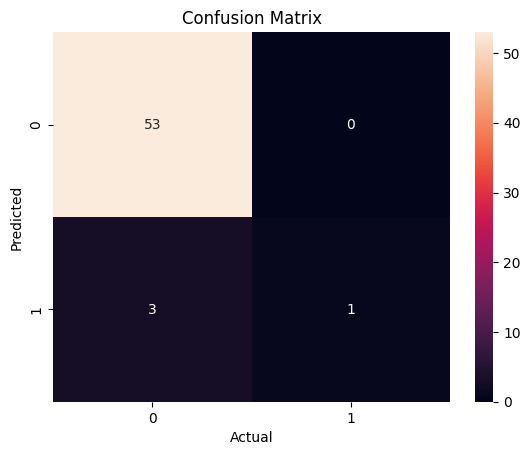

In [390]:
# Evaluate
print("Naive baseline accuracy: %.2f" % naive_baseline_accuracy)
print("=" * 10)
print("Training metrics:")
evaluate_model(logreg, X_train, y_train, plot=False)
print("=" * 10)
print("Test metrics:")
evaluate_model(logreg, X_test, y_test, plot=True);

#### Interpret Model

In [391]:
# Results
logreg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                passive   No. Observations:                  224
Model:                          Logit   Df Residuals:                      210
Method:                           MLE   Df Model:                           13
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                  0.4606
Time:                        16:33:14   Log-Likelihood:                -29.687
converged:                       True   LL-Null:                       -55.040
Covariance Type:            nonrobust   LLR p-value:                 2.254e-06
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
agent_len               0.6534      0.274      2.385      0.017       0.116       1.190
agent_is_pronoun       -3.8937      2.112     -1.843      0.065      -8.034       0.246
agent_is_plural         0.0408      0.830      0.049      0.961      -1.586       1.668
agent_is_animate       -1.5424      0.925     -1.668      0.095      -3.355       0.270
agent_is_definite      -0.6774      0.909     -0.746      0.456      -2.458       1.103
patient_len            -0.0926      0.655     -0.141      0.888      -1.376       1.191
patient_is_pronoun     -0.5422      1.949     -0.278      0.781      -4.362       3.278
patient_is_plural      -1.1310      0.977     -1.157      0.247      -3.046       0.784
patient_is_animate     -0.2408      1.642     -0.147      0.883      -3.459       2.978
patient_is_definite     1.5694      0.946      1.659      0.097      -0.285       3.424
uid_std                -0.1966      0.572     -0.344      0.731      -1.318       0.925
uid_pwd                -1.1229      0.536     -2.096      0.036      -2.173      -0.073
surp_slor               2.6804      0.857      3.126      0.002       1.000       4.361
Intercept              -2.5935      0.802     -3.235      0.001      -4.165      -1.022
=======================================================================================

Possibly complete quasi-separation: A fraction 0.22 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

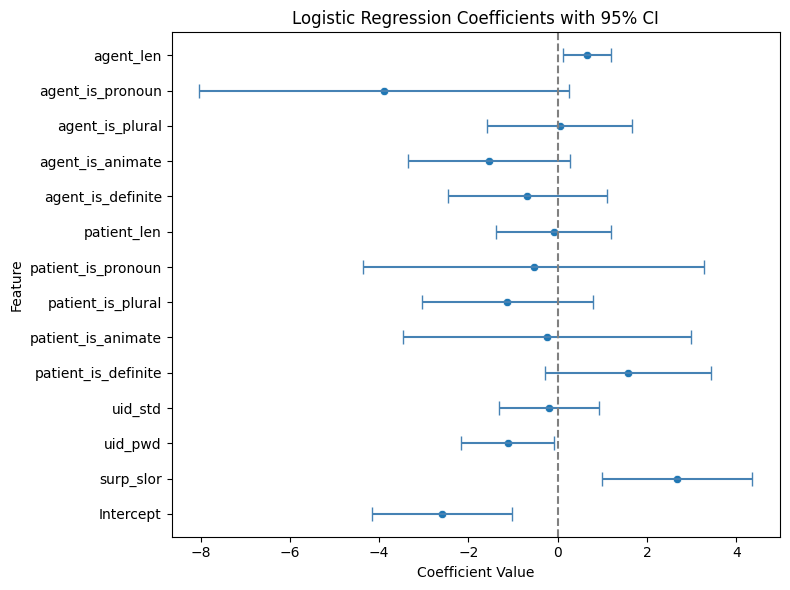

In [392]:
# Plots confidence intervals for coefficients from statsmodels
ci = logreg.conf_int()
ci.columns = ['2.5%', '97.5%']
ci['coef'] = logreg.params
ci = ci.reset_index().rename(columns={'index': 'feature'})
# ci = ci[ci['feature'] != 'Intercept']
plt.figure(figsize=(8, 6))
sns.scatterplot(x=ci['coef'], y=ci['feature'])
x_coords = np.arange(len(ci))
y_coords = ci['coef']
xerr = ci['coef'] - ci['2.5%']
plt.errorbar(x=y_coords, y=x_coords, xerr=xerr, fmt='none', ecolor='steelblue', capsize=5)
plt.axvline(0, color='grey', linestyle='--')
plt.title("Logistic Regression Coefficients with 95% CI")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()